# Import Library

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

In [2]:
path = "../data/raw/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [3]:
downcasting = {
    'step': 'int32',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'string',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'string',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

df = df.astype(downcasting)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        string  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        string  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), string(2)
memory usage: 388.1 MB


In [4]:
df[['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']].to_parquet("../data/processed/fraud_labels.parquet", index=False)
df[['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig','nameDest', 'oldbalanceDest', 'newbalanceDest']].to_parquet("../data/processed/transactions.parquet", index=False)

In [5]:
df_par = pd.read_parquet('../data/processed/transactions.parquet')
df_par.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0


In [8]:
df_par.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [9]:
df_par.duplicated().sum()

np.int64(0)

In [6]:
df_par.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        string  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        string  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
dtypes: category(1), float32(5), int32(1), string(2)
memory usage: 376.0 MB


# Feature Engginering

In [ ]:
idx = 1
errorBalanceOrig = df_par.oldbalanceOrg[idx] - (df_par.amount[idx] + df_par.newbalanceOrig[idx])
errorBalanceDest = df_par.oldbalanceDest[idx] + df_par.amount[idx] - df_par.newbalanceDest[idx]

old:  21249.0
amount :  1864.28
new:  19384.72
horee:  0.0
-=============-
old:  0.0
amount :  1864.28
new:  0.0
1864.28


In [10]:
df_par['hour_of_day'] = df_par['step'] %24
df_par['errorBalanceOrig'] = df_par['newbalanceOrig'] + df_par['amount'] - df_par['oldbalanceOrg']
df_par['is_merchant_dest'] = df_par['nameDest'].str.startswith('M').astype('int8')
df_par['errorBalanceDest'] = np.where(
    df_par['is_merchant_dest'] == 1, 0,
    df_par['oldbalanceDest'] + df_par['amount'] - df_par['newbalanceDest']
)

In [11]:
df_par.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,1,0.0,1,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,1,0.0,1,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0.0,0,181.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0.0,0,21363.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,1,0.0,1,0.0


# Feature Selection

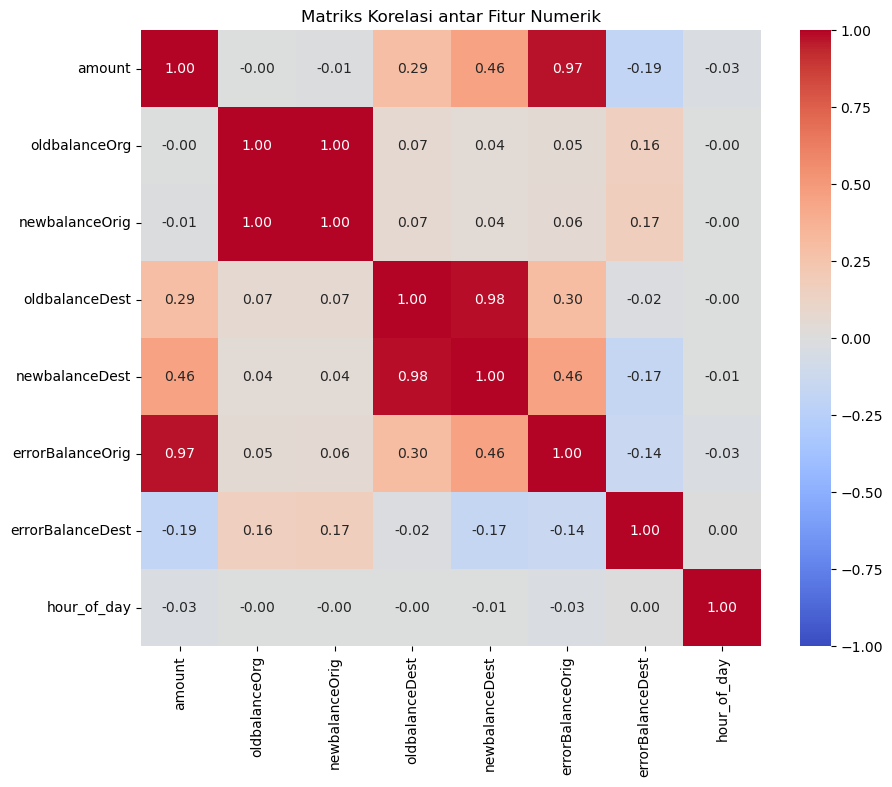

In [15]:
# Correlation Matrix
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest',
       'errorBalanceOrig','errorBalanceDest','hour_of_day']
corr_matrix = df_par[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriks Korelasi antar Fitur Numerik')
plt.show()

In [17]:
# Entropy Calculation
def calculate_entropy(series):
    counts = series.value_counts()
    probabilities = counts / len(series)
    return entropy(probabilities, base=2)
print("\nNilai Entropi Kolom Kategorikal/ID")
print(f"Entropy nameOrig: {calculate_entropy(df['nameOrig'])} bits")
print(f"Entropy nameDest: {calculate_entropy(df['nameDest'])} bits")
print(f"Entropy type: {calculate_entropy(df['type'])} bits")


Nilai Entropi Kolom Kategorikal/ID
Entropy nameOrig: 22.598260340152983 bits
Entropy nameDest: 20.243693811759922 bits
Entropy type: 1.8866307001296543 bits


notes :
- Berdasarkan pada matrix corelation tersebut oldBalanceOrig & newBalanceOrig memiliki hubungan multikolinearitas sempurna 1.00 dan juga oldBalanceDest & newBalanceDest juga punya hubungan multikolinearitas yang tinggi juga di 0.98, yang brarti saldo pergerakan sebelum dan sesudah transaksi itu mirip banget.
- Disini juga amount & errorBalanceOrig juga senilai 0.97 yg artinya fitur untuk deteksi anomali ini sangat dipengaruhi oleh jumlah uang yang dikirimkan.
- Fitur hour_of_day terbukti independen dengan jumlahnya yang mendekati 0 
- Berdasarkan entropy kolom nameOrig dan nameDest memiliki nilai keacakan yang terlalu tinggi hingga mencapai 20+, sehingga fitur ini lebih baik dibuang saja